# German Credit Risk — Logistic Regression

This notebook builds a logistic regression model to predict **bad credit risk** (default) using the German credit dataset.

## Overview: Workflow Steps

1. **Import & Load Data** → Read the German credit CSV and inspect structure.
2. **Explore Data** → Check variable types, basic summaries, and target class balance (good vs bad credit).
3. **Handle Class Imbalance** → Demonstrate how to up-sample the minority class and discuss impact.
4. **Prepare Features** → Create dummy variables for categorical fields and add a constant term.
5. **Train/Test Split** → Split the data into training and testing sets.
6. **Fit Logistic Regression** → Estimate the logit model, interpret coefficients, and write the equation.
7. **Check Multicollinearity** → Compute VIF and select significant variables based on p-values.
8. **Model Evaluation** → Build confusion matrix, compute accuracy, sensitivity, specificity, precision, F1, and Pseudo R².
9. **ROC & Thresholds** → Draw ROC curve and illustrate optimal cut-offs (0.5, Youden’s J, cost-based thresholds).
10. **Decision Tree Extension** → Build classification trees, evaluate performance, and compare with the logistic model.

This structure now mirrors the flow in `renege_model.ipynb`: clear EDA → feature preparation → logistic model fitting → diagnostics → threshold analysis → advanced model comparison.

In [1]:
import pandas as pd
import numpy as np

In [2]:
credit_df = pd.read_csv('german_credit_data.csv')
credit_df.head()

,checkin_acc,duration,credit_history,amount,savings_acc,present_emp_since,inst_rate,personal_status,residing_since,age,inst_plans,num_credits,job,status
0,A11,6,A34,1169,A65,A75,4,A93,4,67,A143,2,A173,0
1,A12,48,A32,5951,A61,A73,2,A92,2,22,A143,1,A173,1
2,A14,12,A34,2096,A61,A74,2,A93,3,49,A143,1,A172,0
3,A11,42,A32,7882,A61,A74,2,A93,4,45,A143,1,A173,0
4,A11,24,A33,4870,A61,A73,3,A93,4,53,A143,2,A173,1


In [3]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   checkin_acc        1000 non-null   object
 1   duration           1000 non-null   int64 
 2   credit_history     1000 non-null   object
 3   amount             1000 non-null   int64 
 4   savings_acc        1000 non-null   object
 5   present_emp_since  1000 non-null   object
 6   inst_rate          1000 non-null   int64 
 7   personal_status    1000 non-null   object
 8   residing_since     1000 non-null   int64 
 9   age                1000 non-null   int64 
 10  inst_plans         1000 non-null   object
 11  num_credits        1000 non-null   int64 
 12  job                1000 non-null   object
 13  status             1000 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 109.5+ KB


In [4]:
# for the dependent variable, checking the count of each label
credit_df.status.value_counts()

status
0    700
1    300
Name: count, dtype: int64

In [5]:
# how to deal with imbalanced data - we include more rows from the minority class
X_features = list(credit_df.columns)
X_features.remove('status') # dependent variable so removed
X_features

['checkin_acc',
 'duration',
 'credit_history',
 'amount',
 'savings_acc',
 'present_emp_since',
 'inst_rate',
 'personal_status',
 'residing_since',
 'age',
 'inst_plans',
 'num_credits',
 'job']

In [6]:
# dummy variables for categorical features
encoded_credit_df = pd.get_dummies(credit_df[X_features], drop_first=True, dtype=int)
encoded_credit_df.head()

,duration,amount,inst_rate,residing_since,age,num_credits,checkin_acc_A12,checkin_acc_A13,checkin_acc_A14,credit_history_A31,...,present_emp_since_A74,present_emp_since_A75,personal_status_A92,personal_status_A93,personal_status_A94,inst_plans_A142,inst_plans_A143,job_A172,job_A173,job_A174
0,6,1169,4,4,67,2,0,0,0,0,...,0,1,0,1,0,0,1,0,1,0
1,48,5951,2,2,22,1,1,0,0,0,...,0,0,1,0,0,0,1,0,1,0
2,12,2096,2,3,49,1,0,0,1,0,...,1,0,0,1,0,0,1,1,0,0
3,42,7882,2,4,45,1,0,0,0,0,...,1,0,0,1,0,0,1,0,1,0
4,24,4870,3,4,53,2,0,0,0,0,...,0,0,0,1,0,0,1,0,1,0


In [7]:
list(encoded_credit_df.columns)

['duration',
 'amount',
 'inst_rate',
 'residing_since',
 'age',
 'num_credits',
 'checkin_acc_A12',
 'checkin_acc_A13',
 'checkin_acc_A14',
 'credit_history_A31',
 'credit_history_A32',
 'credit_history_A33',
 'credit_history_A34',
 'savings_acc_A62',
 'savings_acc_A63',
 'savings_acc_A64',
 'savings_acc_A65',
 'present_emp_since_A72',
 'present_emp_since_A73',
 'present_emp_since_A74',
 'present_emp_since_A75',
 'personal_status_A92',
 'personal_status_A93',
 'personal_status_A94',
 'inst_plans_A142',
 'inst_plans_A143',
 'job_A172',
 'job_A173',
 'job_A174']

In [8]:
y = credit_df.status

# add const column 
import statsmodels.api as sm
X = sm.add_constant(encoded_credit_df)
X.head()

,const,duration,amount,inst_rate,residing_since,age,num_credits,checkin_acc_A12,checkin_acc_A13,checkin_acc_A14,...,present_emp_since_A74,present_emp_since_A75,personal_status_A92,personal_status_A93,personal_status_A94,inst_plans_A142,inst_plans_A143,job_A172,job_A173,job_A174
0,1.0,6,1169,4,4,67,2,0,0,0,...,0,1,0,1,0,0,1,0,1,0
1,1.0,48,5951,2,2,22,1,1,0,0,...,0,0,1,0,0,0,1,0,1,0
2,1.0,12,2096,2,3,49,1,0,0,1,...,1,0,0,1,0,0,1,1,0,0
3,1.0,42,7882,2,4,45,1,0,0,0,...,1,0,0,1,0,0,1,0,1,0
4,1.0,24,4870,3,4,53,2,0,0,0,...,0,0,0,1,0,0,1,0,1,0


In [9]:
# define training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [10]:
# Write the equation of the logistic regression model
# P(y=1|x) = 1 / (1 + e^(-β₀ - β₁x₁ - β₂x₂ - ... - βₙxₙ))

In [11]:
## Running Logistic Regression with all regressors
logit_model = sm.Logit(Y_train, X_train).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.488938
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 status   No. Observations:                  700
Model:                          Logit   Df Residuals:                      670
Method:                           MLE   Df Model:                           29
Date:                Sat, 07 Feb 2026   Pseudo R-squ.:                  0.1980
Time:                        05:09:49   Log-Likelihood:                -342.26
converged:                       True   LL-Null:                       -426.75
Covariance Type:            nonrobust   LLR p-value:                 1.063e-21
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -0.1511      1.135     -0.133      0.894      -2.375       2.

In [12]:
# Optimization terminated successfully. Current function value: 0.488938 Iterations 6
# It is because of MLE, which maximizes the likelihood function to find the best-fitting model parameters.
# The optimization algorithm iteratively adjusts the model parameters to minimize the negative log-likelihood, leading to convergence when the optimal parameters are found.
# In OLS, it was not used because OLS has a closed-form solution that can be computed directly without iterative optimization.

In [13]:
# Checking for multicollinearity using VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

# then pick the significant variables based on p-values

# Function to identify significant variables - can directly use in group assignment 
def get_significant_variables(logit_model):
    var_p_vals_df = pd.DataFrame(logit_model.pvalues)
    var_p_vals_df['vars'] = var_p_vals_df.index
    var_p_vals_df.columns = ['pvals', 'vars']

    return list(var_p_vals_df[var_p_vals_df.pvals <= 0.05]['vars'])

In [14]:
significant_vars = get_significant_variables(logit_model)
significant_vars

['duration',
 'amount',
 'inst_rate',
 'age',
 'checkin_acc_A13',
 'checkin_acc_A14',
 'credit_history_A34',
 'savings_acc_A65']

In [15]:
final_logit_model = sm.Logit(Y_train, sm.add_constant(X_train[significant_vars])).fit()
print(final_logit_model.summary()) # to get the b0 

Optimization terminated successfully.
         Current function value: 0.511350
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 status   No. Observations:                  700
Model:                          Logit   Df Residuals:                      691
Method:                           MLE   Df Model:                            8
Date:                Sat, 07 Feb 2026   Pseudo R-squ.:                  0.1612
Time:                        05:09:49   Log-Likelihood:                -357.94
converged:                       True   LL-Null:                       -426.75
Covariance Type:            nonrobust   LLR p-value:                 7.419e-26
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.8969      0.436     -2.055      0.040      -1.752      -0.042
durat

In [16]:
# Compare AIC and BIC between the two models
print("=" * 70)
print("MODEL COMPARISON: FULL MODEL vs REDUCED MODEL")
print("=" * 70)
print(f"\n{'Metric':<25} {'Full Model':<20} {'Reduced Model':<20}")
print("-" * 70)
print(f"{'Pseudo R-squared':<25} {logit_model.prsquared:<20.4f} {final_logit_model.prsquared:<20.4f}")
print(f"{'AIC':<25} {logit_model.aic:<20.2f} {final_logit_model.aic:<20.2f}")
print(f"{'BIC':<25} {logit_model.bic:<20.2f} {final_logit_model.bic:<20.2f}")
print(f"{'Log-Likelihood':<25} {logit_model.llf:<20.2f} {final_logit_model.llf:<20.2f}")
print(f"{'Number of Parameters':<25} {int(logit_model.df_model + 1):<20} {int(final_logit_model.df_model + 1):<20}")
print("=" * 70)

print("\nINTERPRETATION:")
print("-" * 70)
if final_logit_model.aic < logit_model.aic:
    print(f"✓ REDUCED MODEL WINS on AIC (lower is better)")
    print(f"  AIC Difference: {logit_model.aic - final_logit_model.aic:.2f} points in favor of reduced model")
else:
    print(f"✗ Full model has lower AIC")
    print(f"  AIC Difference: {final_logit_model.aic - logit_model.aic:.2f} points")

if final_logit_model.bic < logit_model.bic:
    print(f"\n✓ REDUCED MODEL WINS on BIC (lower is better)")
    print(f"  BIC Difference: {logit_model.bic - final_logit_model.bic:.2f} points in favor of reduced model")
else:
    print(f"\n✗ Full model has lower BIC")
    print(f"  BIC Difference: {final_logit_model.bic - logit_model.bic:.2f} points")

print("\nCONCLUSION:")
print("-" * 70)
print("The REDUCED MODEL is PREFERABLE because:")
print("1. Lower AIC/BIC indicates better balance of fit and simplicity")
print("2. All variables are statistically significant")
print("3. Fewer variables reduce risk of overfitting")
print("4. More parsimonious and interpretable")
print("5. The slight decrease in pseudo R² (0.198 → 0.161) is a")
print("   worthwhile trade-off for these benefits")
print("=" * 70)

MODEL COMPARISON: FULL MODEL vs REDUCED MODEL

Metric                    Full Model           Reduced Model       
----------------------------------------------------------------------
Pseudo R-squared          0.1980               0.1612              
AIC                       744.51               733.89              
BIC                       881.05               774.85              
Log-Likelihood            -342.26              -357.94             
Number of Parameters      30                   9                   

INTERPRETATION:
----------------------------------------------------------------------
✓ REDUCED MODEL WINS on AIC (lower is better)
  AIC Difference: 10.62 points in favor of reduced model

✓ REDUCED MODEL WINS on BIC (lower is better)
  BIC Difference: 106.20 points in favor of reduced model

CONCLUSION:
----------------------------------------------------------------------
The REDUCED MODEL is PREFERABLE because:
1. Lower AIC/BIC indicates better balance of fit and 

## Model Comparison: Trade-off Analysis

When we reduced the model from 29 predictors to 8 significant variables, we observe:
- **Full Model Pseudo R²**: 0.1980
- **Reduced Model Pseudo R²**: 0.1612

The pseudo R-square decreased because we removed variables that, while potentially affected by multicollinearity, still contributed to explaining variance in the outcome.

### Why Lower Pseudo R² Can Still Be Better:
1. **Reduced Model Benefits**:
   - All variables are statistically significant (p < 0.05)
   - Better interpretability with fewer variables
   - Reduced multicollinearity issues
   - Better generalization to unseen data (less overfitting)
   - Simpler, more parsimonious model

2. **Trade-off**:
   - Slight decrease in training fit (pseudo R²)
   - Potential improvement in test set performance (generalization)
   - More reliable coefficient estimates

### Resolution: Information Criteria Comparison
AIC (Akaike Information Criterion) and BIC (Bayesian Information Criterion) balance model fit with complexity by penalizing models with more parameters. Lower values are better.

In [17]:
# the coeff of vars are not drastically changed and p-values are less than 0.05
# there can be changes in coeff values due multicollinearity removal
# we can check VIF again to confirm

In [18]:
# Pseudo R² is a goodness-of-fit measure for logistic regression that compares 
# your model to a null (intercept-only) model.
# It shows how much better the model explains the outcome than having no predictors, 
# but it is not the same as OLS R² (values are usually much smaller).

# pseudo R² = 1 - (LL_model / LL_null)
# where LL_model is the log-likelihood of your fitted model and 
# LL_null is the log-likelihood of the null model.

In [19]:
#Predicting on test set
Y_pred_prob = final_logit_model.predict(sm.add_constant(X_test[significant_vars]))
Y_pred_df = pd.DataFrame({'actual': Y_test, 'predicted_prob': Y_pred_prob})
Y_pred_df.head()

,actual,predicted_prob
521,1,0.452449
737,0,0.491820
740,0,0.418416
660,0,0.270285
411,0,0.132119


In [20]:
# create another column and check with the threshold of 0.5. Convert probabilities to class labels
Y_pred_df['predicted'] = Y_pred_df['predicted_prob'].map(lambda x: 1 if x > 0.5 else 0)
Y_pred_df.head()

,actual,predicted_prob,predicted
521,1,0.452449,0
737,0,0.491820,0
740,0,0.418416,0
660,0,0.270285,0
411,0,0.132119,0


In [21]:
# 1 is bad credit, 0 is good credit
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(Y_pred_df['actual'], Y_pred_df['predicted']) # overall how many are correctly classified
precision = precision_score(Y_pred_df['actual'], Y_pred_df['predicted']) # of predicted positives how many are actual positive
recall = recall_score(Y_pred_df['actual'], Y_pred_df['predicted']) # sensitivity - of all actual positives how many are predicted positive
f1 = f1_score(Y_pred_df['actual'], Y_pred_df['predicted']) # harmonic mean of precision and recall

In [22]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.7266666666666667
Precision: 0.5882352941176471
Recall: 0.32967032967032966
F1 Score: 0.4225352112676056


In [23]:
conf_matrix = confusion_matrix(Y_pred_df['actual'], Y_pred_df['predicted']) # rows: actual, cols: predicted
# it is needed to print after calculating all metrics
print("Confusion Matrix:\n", conf_matrix)

Confusion Matrix:
 [[188  21]
 [ 61  30]]


In [24]:
# creating confusion matrix using seaborn heatmap
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import metrics

In [25]:
def draw_cm(actual, predicted):
    cm = metrics.confusion_matrix(actual, predicted, labels=[0,1])

    sns.heatmap(cm, annot=True, fmt='.2f', 
                cmap='Blues', 
                xticklabels=['Bad Credit', 'Good Credit'], 
                yticklabels=['Bad Credit', 'Good Credit'])
    plt.ylabel('Actual/True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix')
    plt.show()

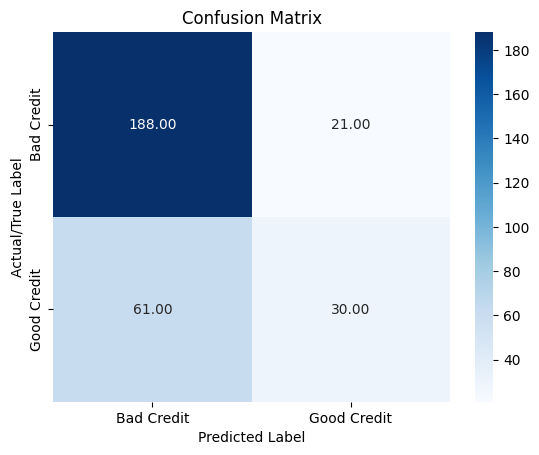

In [26]:
draw_cm(Y_pred_df['actual'], Y_pred_df['predicted'])

In [27]:
# sensitivity = TP/(TP + FN)
# Specificity = TN/(TN + FP)
# Precision = TP/(TP + FP)
# F-Score = 2 * (Precision * Recall) / (Precision + Recall)
# Accuracy = (TP + TN) / (TP + TN + FP + FN)

In [28]:
# get performance metrics 
print(metrics.classification_report(Y_pred_df['actual'], Y_pred_df['predicted']))

              precision    recall  f1-score   support

           0       0.76      0.90      0.82       209
           1       0.59      0.33      0.42        91

    accuracy                           0.73       300
   macro avg       0.67      0.61      0.62       300
weighted avg       0.70      0.73      0.70       300



In [29]:
# ROC Code
import matplotlib.pyplot as plt

# We're creating a function named 'draw_roc' that will return ROC curve:

def draw_roc(actual, probs):
    fpr, tpr, thresholds = metrics.roc_curve(actual, probs, drop_intermediate=False)
    auc_score = metrics.roc_auc_score(actual, probs)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label='ROC curve (AUC = %0.2f)' % auc_score, color='blue')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    return fpr, tpr, thresholds


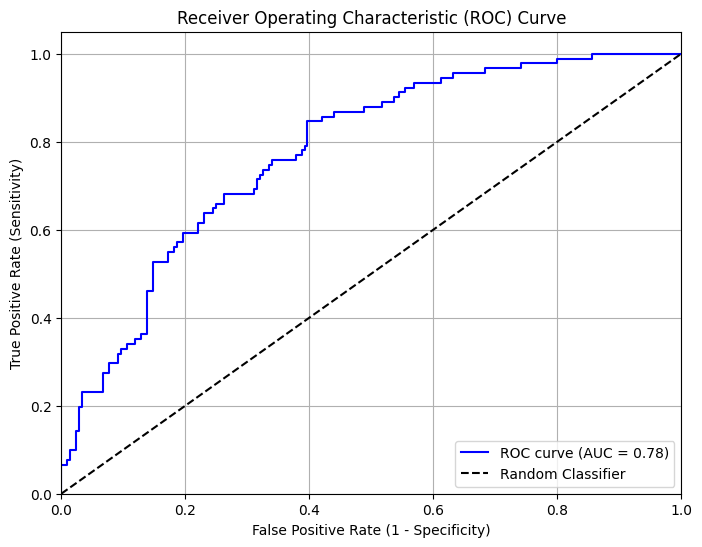

In [30]:
fpr, tpr, thresholds = draw_roc(Y_pred_df['actual'], Y_pred_df['predicted_prob'])

In [31]:
# X-axis: False Positive Rate (1 - Specificity)
# Y-axis: True Positive Rate (Sensitivity/Recall)
# Diagonal line: Random classifier (AUC = 0.5)

In [32]:
auc_score = metrics.roc_auc_score(Y_pred_df['actual'], Y_pred_df['predicted_prob'])
auc_score

0.7758557232241443

In [33]:
## Calculating AUC Score
# If ROC is 0.5, it means the model has no discrimination ability between the positive and negative classes; 
# it's equivalent to random guessing. An AUC of 0.5 indicates that the model is not useful for classification tasks.
# 0.5 - no discrimination
# 0.7 <= ROC area < 0.8 - acceptable discrimination
# 0.8 <= ROC area < 0.9 - excellent discrimination
# ROC area >= 0.9 - outstanding discrimination

## Optimal Threshold

In [34]:
# how to determine the optimal threshold?

# One common method to determine the optimal threshold is to use Youden's J statistic, 
# which maximizes the difference between the true positive rate (sensitivity) and 
# the false positive rate (1 - specificity). 

# The optimal threshold is the point on the ROC curve that is farthest from the diagonal line 
# (random classifier line).

# Youden's J statistic = sensitivity + specificity - 1 = should be maximized

# total 3 methods = cost based approach, Youden's J statistic, classification plots

In [35]:
# Cost based approach: there are 2 types of costs
# 1. Cost of misclassifying a bad credit customer as good credit (False Negative)
# 2. Cost of misclassifying a good credit customer as bad credit (False Positive)
# Depending on the business context, one type of misclassification may be more costly than the other.
# For example, in credit risk assessment, misclassifying a bad credit customer as good credit
# may lead to higher financial losses compared to misclassifying a good credit customer as bad credit

In [36]:
# Youden's index
tpr_fpr = pd.DataFrame({'fpr': fpr, 'tpr': tpr, 'thresholds': thresholds})
tpr_fpr['diff'] = tpr_fpr['tpr'] - tpr_fpr['fpr']
tpr_fpr.sort_values(by='diff', ascending=False)[0:5]
# tpr_fpr.head()

,fpr,tpr,thresholds,diff
160,0.397129,0.846154,0.221534,0.449025
161,0.401914,0.846154,0.216531,0.444240
162,0.406699,0.846154,0.215591,0.439455
159,0.397129,0.835165,0.223980,0.438036
166,0.421053,0.857143,0.207107,0.436090


In [37]:
best_threshold = min(tpr_fpr['thresholds'])

Y_pred_df['predicted_new'] = Y_pred_df['predicted_prob'].map(lambda x: 1 if x > best_threshold else 0)

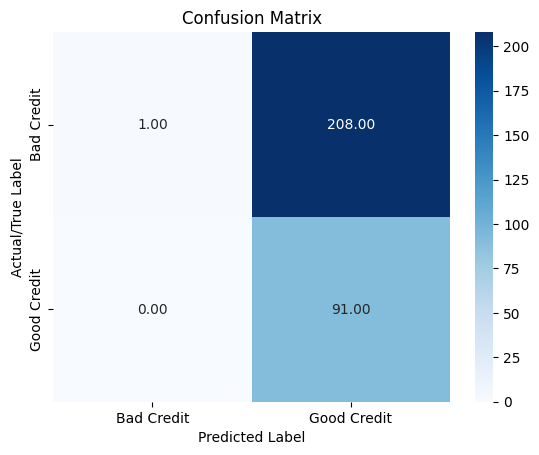

In [38]:
# confusion matrix corresponding to new threshold
draw_cm(Y_pred_df['actual'], Y_pred_df['predicted_new'])

In [39]:
print(metrics.classification_report(Y_pred_df['actual'], Y_pred_df['predicted_new']))

              precision    recall  f1-score   support

           0       1.00      0.00      0.01       209
           1       0.30      1.00      0.47        91

    accuracy                           0.31       300
   macro avg       0.65      0.50      0.24       300
weighted avg       0.79      0.31      0.15       300



In [40]:
# cost based approach
from sklearn import metrics
import numpy as np

# Function to calculate total cost based on FP and FN costs

def get_total_cost(actual, predicted, cost_fp, cost_fn):
    cm = metrics.confusion_matrix(actual, predicted, labels=[1, 0])
    tp = cm[0, 0]
    fn = cm[0, 1]
    fp = cm[1, 0]
    tn = cm[1, 1]
    total_cost = (fn * cost_fn) + (fp * cost_fp)
    return total_cost

In [41]:
cost_df = pd.DataFrame(columns=['threshold', 'cost'])
idx = 0

# iterate over cut-off probabilities between 0.1 and 0.49
for each_prob in range(10, 50):
    threshold = each_prob / 100

    predicted = Y_pred_df['predicted_prob'].map(lambda x: 1 if x > threshold else 0)

    cost = get_total_cost(Y_pred_df['actual'], predicted, cost_fp=1, cost_fn=5)
    # Assuming cost of FP mis-classification = 1 and cost of FN mis-classification = 5

    cost_df.loc[idx] = [threshold, cost]
    idx += 1

In [42]:
cost_df.sort_values('cost', ascending=True).head(5)

,threshold,cost
4,0.14,150.0
12,0.22,153.0
10,0.20,154.0
2,0.12,154.0
5,0.15,156.0


In [43]:
# Capture the value of 'threshold' for which 'cost' is minimum
# This is the optimal cut-off probability based on Cost-based approach.
# Calling this as 'best_threshold_cost'


best_threshold_cost = cost_df.loc[cost_df['cost'].idxmin(), 'threshold']

best_threshold_cost

np.float64(0.14)

In [44]:
# Updating the predicted y:

Y_pred_df['predicted_using_cost'] = Y_pred_df.predicted_prob.map(
    lambda x: 1 if x > best_threshold_cost else 0
)


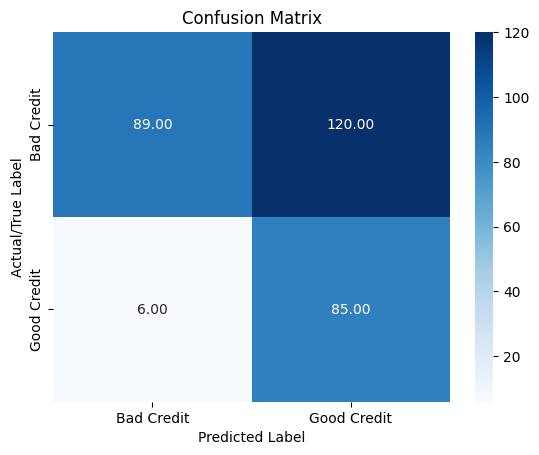

In [45]:
draw_cm( Y_pred_df.actual,

Y_pred_df.predicted_using_cost )

In [46]:
print(metrics.classification_report( Y_pred_df.actual,Y_pred_df.predicted_using_cost))

              precision    recall  f1-score   support

           0       0.94      0.43      0.59       209
           1       0.41      0.93      0.57        91

    accuracy                           0.58       300
   macro avg       0.68      0.68      0.58       300
weighted avg       0.78      0.58      0.58       300



In [47]:
# the optimal threshold for log reg is 0.5
# youden index is p =0.22
# cost based is 0.14

## Decision Tree

In [48]:
from sklearn.tree import DecisionTreeClassifier
clf_tree = DecisionTreeClassifier(criterion='gini', max_depth=3)

In [49]:
clf_tree.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

[Text(0.5, 0.875, 'checkin_acc_A14 <= 0.5\ngini = 0.419\nsamples = 700\nvalue = [491.0, 209.0]\nclass = y[0]'),
 Text(0.25, 0.625, 'duration <= 33.0\ngini = 0.484\nsamples = 425\nvalue = [251, 174]\nclass = y[0]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'amount <= 10975.5\ngini = 0.458\nsamples = 343\nvalue = [221, 122]\nclass = y[0]'),
 Text(0.0625, 0.125, 'gini = 0.451\nsamples = 337\nvalue = [221, 116]\nclass = y[0]'),
 Text(0.1875, 0.125, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]\nclass = y[1]'),
 Text(0.375, 0.375, 'savings_acc_A65 <= 0.5\ngini = 0.464\nsamples = 82\nvalue = [30, 52]\nclass = y[1]'),
 Text(0.3125, 0.125, 'gini = 0.431\nsamples = 70\nvalue = [22, 48]\nclass = y[1]'),
 Text(0.4375, 0.125, 'gini = 0.444\nsamples = 12\nvalue = [8, 4]\nclass = y[0]'),
 Text(0.75, 0.625, 'inst_plans_A143 <= 0.5\ngini = 0.222\nsamples = 275\nvalue = [240.0, 35.0]\nclass = y[0]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'residing_since <= 2.5\ngini = 0.423\nsamples = 

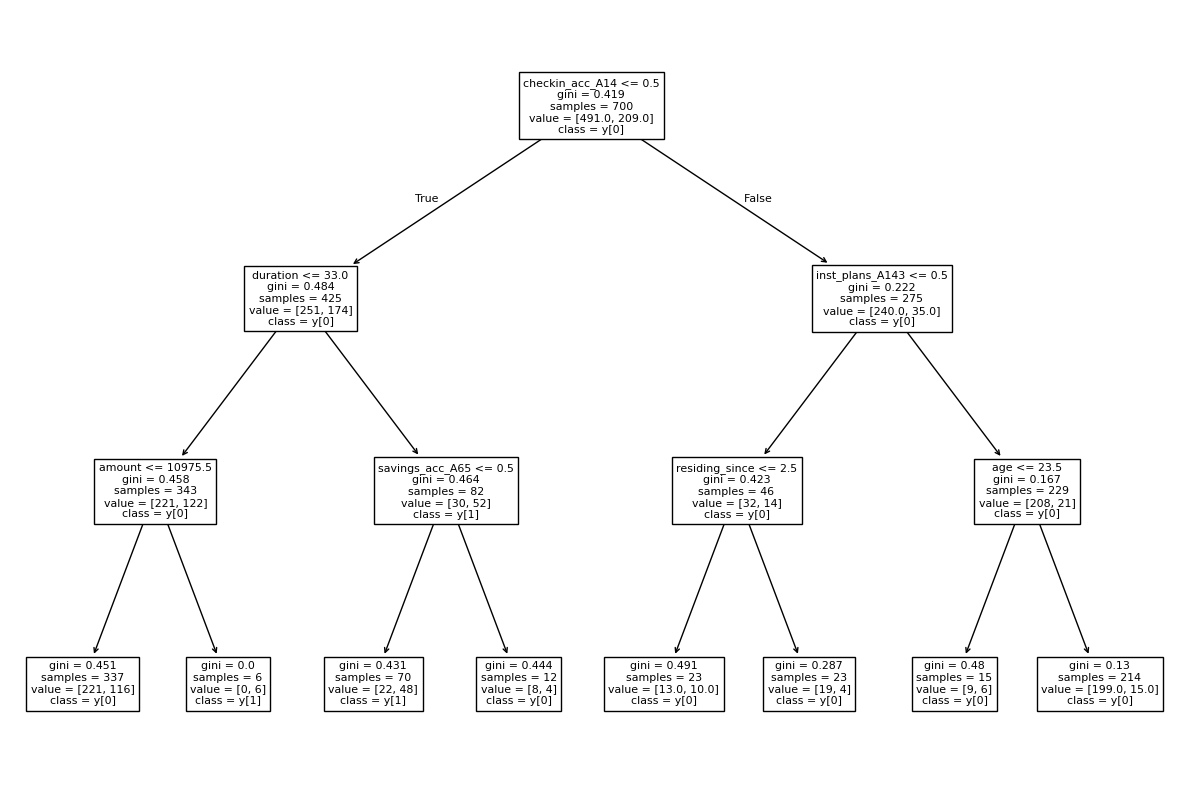

In [50]:
# Display the Decision Tree
from sklearn import tree
plt.figure(figsize=(15,10))

tree.plot_tree(clf_tree, feature_names=X_train.columns, class_names=True)

In [51]:
# [0, 1] - [491, 209]
# good credit - 0
# bad credit - 1

In [52]:
# calculating gini index for first node
gini_node1 = (491/700)*(1-(491/700)) + (209/700)*(1-(209/700))
gini_node1

0.41885306122448984

In [53]:
# measuring test accuracy
tree_predict = clf_tree.predict(X_test)

# Check ROC 
metrics.roc_auc_score(Y_test, tree_predict)

0.5835743204164258

In [54]:
# gini impurity is highest

In [55]:
# Another CART model with entropy as the splitting criterion
from sklearn.tree import DecisionTreeClassifier
clf_tree_entrophy = DecisionTreeClassifier(criterion='entropy', max_depth=3)

In [56]:
clf_tree_entrophy.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

[Text(0.5, 0.875, 'checkin_acc_A14 <= 0.5\nentropy = 0.88\nsamples = 700\nvalue = [491.0, 209.0]\nclass = y[0]'),
 Text(0.25, 0.625, 'duration <= 33.0\nentropy = 0.976\nsamples = 425\nvalue = [251, 174]\nclass = y[0]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'amount <= 10975.5\nentropy = 0.939\nsamples = 343\nvalue = [221, 122]\nclass = y[0]'),
 Text(0.0625, 0.125, 'entropy = 0.929\nsamples = 337\nvalue = [221, 116]\nclass = y[0]'),
 Text(0.1875, 0.125, 'entropy = 0.0\nsamples = 6\nvalue = [0, 6]\nclass = y[1]'),
 Text(0.375, 0.375, 'present_emp_since_A75 <= 0.5\nentropy = 0.947\nsamples = 82\nvalue = [30, 52]\nclass = y[1]'),
 Text(0.3125, 0.125, 'entropy = 0.983\nsamples = 66\nvalue = [28, 38]\nclass = y[1]'),
 Text(0.4375, 0.125, 'entropy = 0.544\nsamples = 16\nvalue = [2, 14]\nclass = y[1]'),
 Text(0.75, 0.625, 'inst_plans_A143 <= 0.5\nentropy = 0.55\nsamples = 275\nvalue = [240.0, 35.0]\nclass = y[0]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'residing_since 

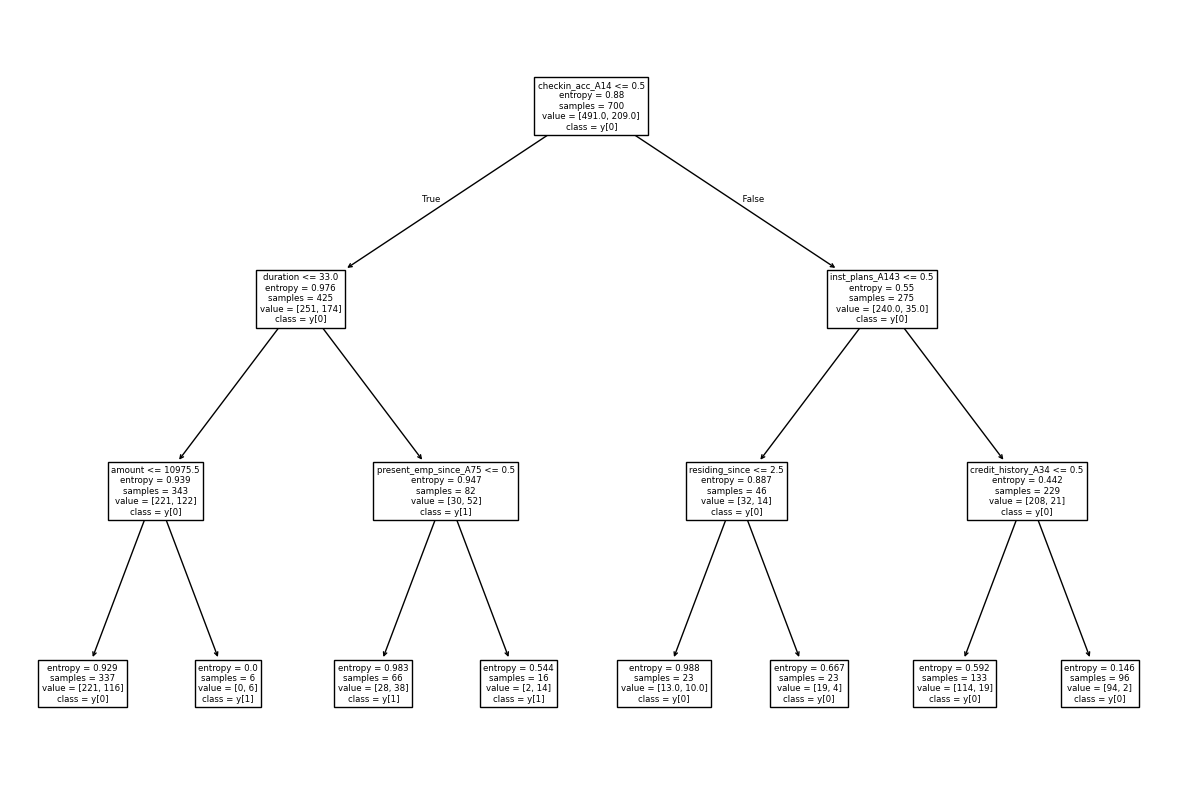

In [57]:
# Display the Decision Tree
from sklearn import tree
plt.figure(figsize=(15,10))

tree.plot_tree(clf_tree_entrophy, feature_names=X_train.columns, class_names=True)

In [58]:
# interpretation of the decision tree
# The decision tree splits the data based on the most informative features to minimize impurity.
# The root node represents the most significant feature for splitting the data.
# Each internal node represents a decision based on a feature value.
# The leaf nodes represent the final classification predictions.
# always mention the support (i.e., number of samples in each node)

In [59]:
tree_predict = clf_tree_entrophy.predict(X_test)

# Check ROC 
metrics.roc_auc_score(Y_test, tree_predict)

0.5763972869236027

# Cross Validation

In [60]:
# k-fold cross validation
# benefit - ensures that no overfitting

# grid search
# params here are max_depth and splitting criteria
# tuning of hyper parameters

In [61]:
# Finding Optimal Criteria & Max Depth
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [62]:
tuned_parameters = [{'criterion': ['gini', 'entropy'], 'max_depth': range(3,10)}]

In [63]:
clf_tree = DecisionTreeClassifier()
clf = GridSearchCV(clf_tree, tuned_parameters, cv=10, scoring='roc_auc')

clf.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'criterion': ['gini', 'entropy'], 'max_depth': range(3, 10)}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed

In [64]:
print("Best parameters:", clf.best_params_)

Best parameters: {'criterion': 'gini', 'max_depth': 4}


In [65]:
print("Best cross-validation AUC score:", clf.best_score_)

Best cross-validation AUC score: 0.6833090864917397
